# Bài thực hành chương 2 - Phần 2

## Canny Edge Detector

Notebook này giải phần nâng cao về thuật toán Canny Edge Detector. Mỗi cell bài tập có thể chạy độc lập và đều có phần **Input**, **Output**, chú thích thuật toán và code minh họa.

## Chuẩn bị thư viện và dữ liệu ảnh

**Input:** môi trường Python và một ảnh bất kỳ.

**Output:** ảnh gốc, ảnh xám và các kết quả xử lý khác nhau để kiểm thử Canny.

**Thuật toán:** đọc ảnh có sẵn bằng OpenCV, chuyển sang ảnh xám rồi dùng các bước phát hiện cạnh để quan sát kết quả.

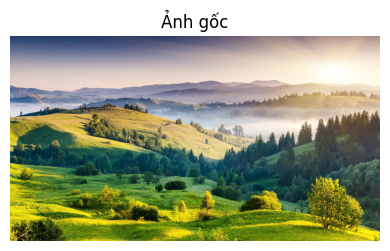

In [1]:
# !pip install opencv-python matplotlib numpy scikit-image
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import feature, img_as_ubyte
from skimage.color import rgb2gray

IMAGE_PATH = 'image/sample_chapter_part_2.jpg'
OUTPUT_DIR = Path('outputs_chapter_2_part_2')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
gray_float = rgb2gray(image_rgb)

def show_images(items, cols=None):
    cols = cols or len(items)
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images([('Ảnh gốc', image_rgb)])


# I. Lý thuyết

## Câu I.1. Tìm hiểu các bước của thuật toán Canny

**Input:** ảnh xám.

**Output:** ảnh biên mảnh và ít nhiễu.

**Thuật toán Canny gồm 5 bước chính:**

1. **Giảm nhiễu:** dùng Gaussian filter làm mượt ảnh, tránh nhiễu bị nhận nhầm là cạnh.
2. **Tính gradient:** dùng đạo hàm theo hướng x và y để tìm nơi cường độ sáng thay đổi mạnh.
3. **Tính độ lớn và hướng gradient:** độ lớn cho biết cạnh mạnh hay yếu, hướng gradient cho biết cạnh đổi sáng theo hướng nào.
4. **Non-maximum suppression:** giữ lại pixel lớn nhất theo hướng gradient để làm cạnh mảnh.
5. **Double threshold và hysteresis:** dùng ngưỡng thấp/ngưỡng cao để giữ cạnh mạnh, loại cạnh yếu không liên thông với cạnh mạnh.

**So sánh với Sobel và Laplacian:** Sobel và Laplacian thường tạo cạnh dày hoặc nhạy nhiễu hơn. Canny có thêm làm mượt, làm mảnh cạnh và nối cạnh bằng hysteresis nên kết quả ổn định hơn.

## Minh họa các bước gần đúng của Canny

**Input:** ảnh xám.

**Output:** ảnh Gaussian blur, gradient X/Y, độ lớn gradient và Canny cuối cùng.

**Thuật toán:** dùng Gaussian để giảm nhiễu, Sobel để tính gradient, sau đó dùng `cv2.Canny` cho kết quả cuối.

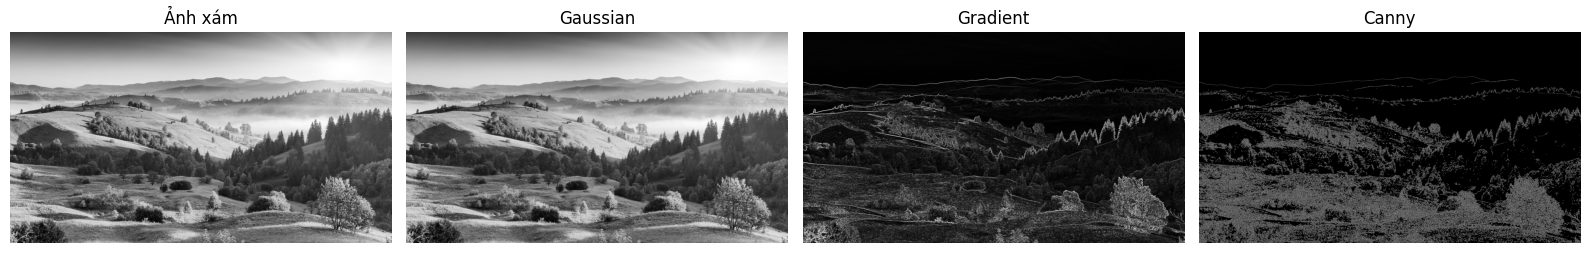

In [2]:
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
gradient = cv2.convertScaleAbs(cv2.magnitude(gx, gy))
canny = cv2.Canny(gray, 80, 160)

show_images([
    ('Ảnh xám', gray), ('Gaussian', blurred),
    ('Gradient', gradient), ('Canny', canny),
])


## Câu I.2. Tham số quan trọng và ảnh hưởng

**Input:** ảnh xám và các tham số `sigma`, `threshold_low`, `threshold_high`.

**Output:** các ảnh biên khác nhau.

**Ý nghĩa tham số:**

- `sigma`: độ mượt của Gaussian filter. Sigma lớn giảm nhiễu tốt hơn nhưng có thể làm mất cạnh nhỏ.
- `threshold_low`: ngưỡng thấp. Ngưỡng thấp nhỏ giữ nhiều cạnh yếu hơn nhưng dễ giữ nhiễu.
- `threshold_high`: ngưỡng cao. Ngưỡng cao lớn chỉ giữ cạnh thật mạnh nhưng có thể làm đứt cạnh.

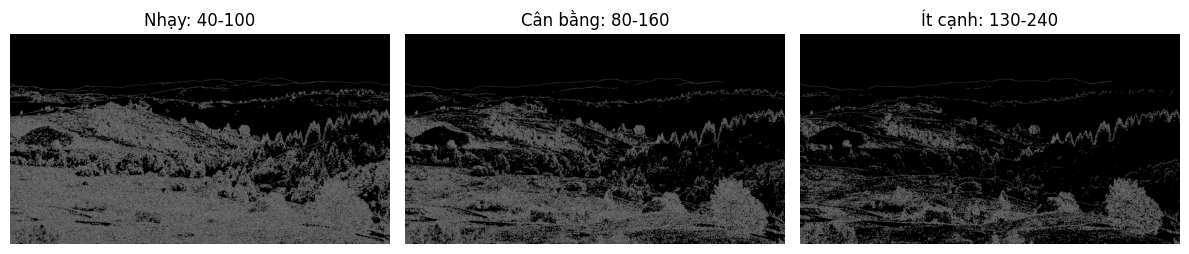

In [3]:
settings = [('Nhạy', 40, 100), ('Cân bằng', 80, 160), ('Ít cạnh', 130, 240)]
results = [(f'{name}: {low}-{high}', cv2.Canny(gray, low, high))
           for name, low, high in settings]
show_images(results)


## Câu I.3. Ưu điểm, nhược điểm và ứng dụng của Canny

**Ưu điểm:** cạnh mảnh, giảm nhiễu tốt, có cơ chế nối cạnh yếu với cạnh mạnh, thường chính xác hơn Sobel/Prewitt đơn giản.

**Nhược điểm:** phụ thuộc tham số ngưỡng, chạy chậm hơn các toán tử đơn giản, ảnh nhiễu mạnh vẫn cần tiền xử lý tốt.

**Ứng dụng thực tế:** phát hiện vật thể, kiểm tra lỗi sản phẩm, nhận dạng biển báo/biển số, trích biên trong ảnh y tế, phân đoạn ảnh, hỗ trợ nhận dạng hình dạng.

# II. Bài tập thực hành

## Câu II.1. Thực hiện Canny bằng OpenCV và Scikit-image

**Input:** ảnh xám.

**Output:** ảnh biên từ OpenCV và ảnh biên từ Scikit-image.

**Thuật toán:**
1. OpenCV dùng `cv2.Canny(gray, threshold1, threshold2)`.
2. Scikit-image dùng `feature.canny(image, sigma, low_threshold, high_threshold)` với ảnh dạng số thực trong khoảng `[0, 1]`.

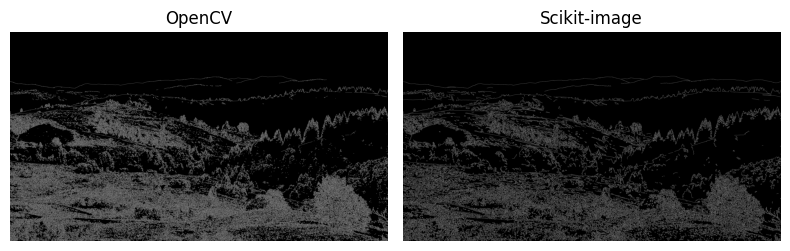

In [4]:
opencv_edges = cv2.Canny(gray, 80, 160)
skimage_edges = img_as_ubyte(feature.canny(
    gray_float, sigma=1.4, low_threshold=0.10, high_threshold=0.25
))

cv2.imwrite(str(OUTPUT_DIR / 'II_1_canny_opencv.png'), opencv_edges)
cv2.imwrite(str(OUTPUT_DIR / 'II_1_canny_skimage.png'), skimage_edges)
show_images([('OpenCV', opencv_edges), ('Scikit-image', skimage_edges)])


## Câu II.2. Thay đổi tham số và quan sát kết quả

**Input:** ảnh xám và nhiều bộ tham số `sigma`, ngưỡng thấp, ngưỡng cao.

**Output:** bảng ảnh so sánh kết quả Canny.

**Thuật toán:** lặp qua nhiều bộ tham số, chạy Canny và hiển thị cạnh nhau để rút nhận xét.

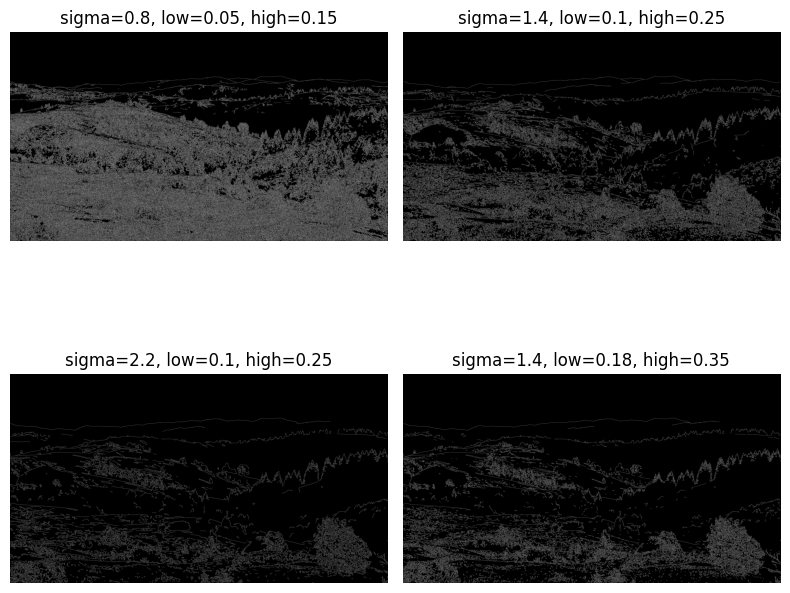

In [5]:
configs = [(0.8, 0.05, 0.15), (1.4, 0.10, 0.25),
           (2.2, 0.10, 0.25), (1.4, 0.18, 0.35)]
results = [
    (f'sigma={s}, low={low}, high={high}',
     feature.canny(gray_float, sigma=s, low_threshold=low, high_threshold=high))
    for s, low, high in configs
]
show_images(results, cols=2)


## Câu II.3. Áp dụng Canny cho nhiều loại ảnh khác nhau

**Input:** ảnh gốc, ảnh nhiễu, ảnh tương phản thấp và ảnh nhiều chi tiết.

**Output:** kết quả Canny trên từng loại ảnh.

**Thuật toán:** tạo các biến thể ảnh, chuyển sang xám, chạy Canny với cùng bộ tham số để đánh giá độ ổn định.

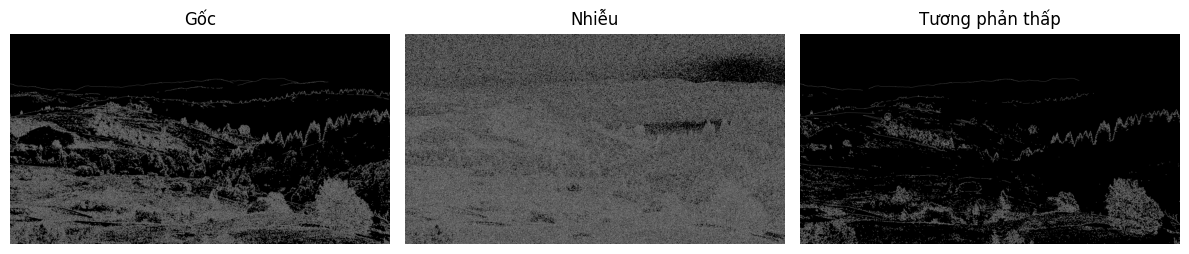

In [6]:
rng = np.random.default_rng(21)
noise = rng.normal(0, 28, image_bgr.shape).astype(np.int16)
noisy = np.clip(image_bgr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
low_contrast = cv2.convertScaleAbs(image_bgr, alpha=0.45, beta=70)

variants = [('Gốc', image_bgr), ('Nhiễu', noisy), ('Tương phản thấp', low_contrast)]
edges = [(name, cv2.Canny(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 80, 160))
         for name, img in variants]
show_images(edges)


## Câu II.4. Kết hợp Canny với các kỹ thuật khác

**Input:** ảnh gốc.

**Output:** ảnh biên sau morphology, các contour và nhãn nhận dạng hình dạng cơ bản.

**Thuật toán:**
1. Chạy Canny để lấy biên.
2. Dùng morphology close/dilate để nối các đoạn biên bị đứt.
3. Dùng `cv2.findContours` tìm vùng khép kín.
4. Xấp xỉ contour bằng `cv2.approxPolyDP` để nhận dạng tam giác, tứ giác, hình tròn gần đúng.

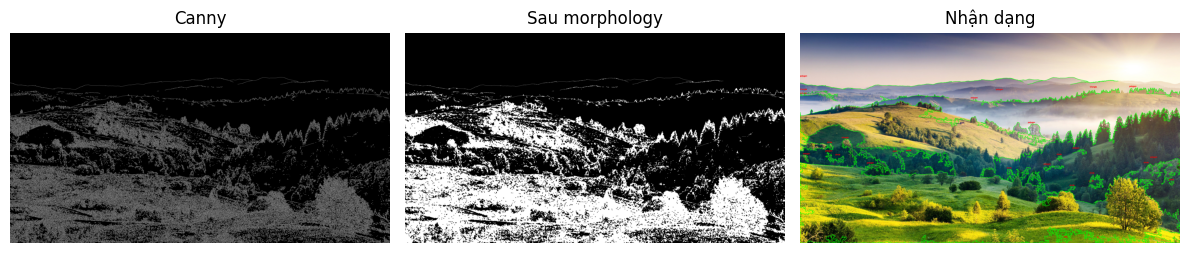

In [7]:
edges = cv2.Canny(gray, 80, 160)
kernel = np.ones((3, 3), np.uint8)
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = image_bgr.copy()
for contour in contours:
    if cv2.contourArea(contour) < 700:
        continue
    vertices = len(cv2.approxPolyDP(contour, 0.03 * cv2.arcLength(contour, True), True))
    label = {3: 'triangle', 4: 'rectangle'}.get(vertices, 'circle' if vertices > 6 else 'polygon')
    x, y, w, h = cv2.boundingRect(contour)
    cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
    cv2.putText(result, label, (x, max(25, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

show_images([
    ('Canny', edges),
    ('Sau morphology', edges_closed),
    ('Nhận dạng', cv2.cvtColor(result, cv2.COLOR_BGR2RGB)),
])


# III. Các câu hỏi mở rộng

## Câu III.1. Làm thế nào để đánh giá chất lượng cạnh phát hiện bởi Canny?

Có thể đánh giá bằng cách so sánh với ảnh biên chuẩn nếu có nhãn, dùng các độ đo precision, recall, F1-score. Nếu không có nhãn, có thể đánh giá trực quan theo các tiêu chí: cạnh có mảnh không, có bị đứt nhiều không, có nhiều cạnh giả do nhiễu không, các biên quan trọng của vật thể có được giữ không.

## Câu III.2. Phương pháp cải thiện hiệu suất Canny

- Tiền xử lý bằng Gaussian blur, median filter hoặc bilateral filter để giảm nhiễu.
- Chọn ngưỡng tự động bằng histogram hoặc Otsu thay vì đặt tay.
- Resize ảnh nếu ảnh quá lớn và không cần độ phân giải đầy đủ.
- Chỉ xử lý vùng quan tâm ROI thay vì toàn bộ ảnh.
- Với video, có thể xử lý cách frame hoặc dùng GPU nếu cần thời gian thực.

## Câu III.3. Canny có dùng cho ảnh màu không?

Canny trong OpenCV thường nhận ảnh xám. Với ảnh màu, cách phổ biến là chuyển RGB/BGR sang grayscale rồi chạy Canny. Nếu muốn tận dụng thông tin màu, có thể chạy Canny trên từng kênh màu hoặc trên các kênh trong HSV/LAB, sau đó kết hợp kết quả bằng phép OR.

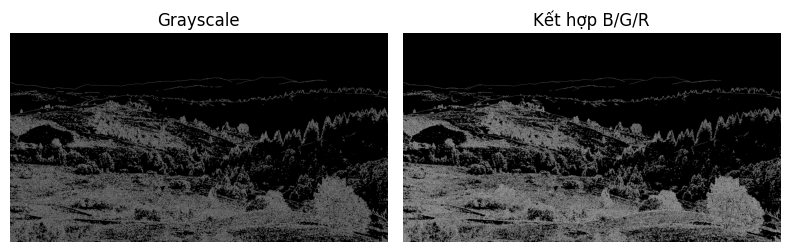

In [8]:
channel_edges = [cv2.Canny(channel, 80, 160) for channel in cv2.split(image_bgr)]
color_edges = cv2.bitwise_or(cv2.bitwise_or(channel_edges[0], channel_edges[1]), channel_edges[2])

cv2.imwrite(str(OUTPUT_DIR / 'III_3_canny_color_channels.png'), color_edges)
show_images([('Grayscale', cv2.Canny(gray, 80, 160)), ('Kết hợp B/G/R', color_edges)])


## Câu III.4. Áp dụng Canny cho video

Để áp dụng Canny cho video, đọc từng frame bằng `cv2.VideoCapture`, chuyển frame sang grayscale, làm mượt, chạy `cv2.Canny`, sau đó hiển thị hoặc ghi ra video mới bằng `cv2.VideoWriter`.

**Pseudocode:**

```python
cap = cv2.VideoCapture('input.mp4')
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 1.4)
    edges = cv2.Canny(gray, 80, 160)
    cv2.imshow('edges', edges)
cap.release()
cv2.destroyAllWindows()
```

Khi xử lý video cần chú ý tốc độ frame, kích thước ảnh và độ ổn định tham số giữa các frame.